<a href="https://colab.research.google.com/github/ayusshs/IPL_WINNING_TEAM/blob/main/IPLWINNINGTEAM_PREDICTION.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [31]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [32]:
data = pd.read_csv('data.csv')

In [33]:
data = pd.read_csv('data.csv')

In [34]:
data.shape

(76014, 15)

In [35]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76014 entries, 0 to 76013
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   mid             76014 non-null  int64  
 1   date            76014 non-null  object 
 2   venue           76014 non-null  object 
 3   batting_team    76014 non-null  object 
 4   bowling_team    76014 non-null  object 
 5   batsman         76014 non-null  object 
 6   bowler          76014 non-null  object 
 7   runs            76014 non-null  int64  
 8   wickets         76014 non-null  int64  
 9   overs           76014 non-null  float64
 10  runs_last_5     76014 non-null  int64  
 11  wickets_last_5  76014 non-null  int64  
 12  striker         76014 non-null  int64  
 13  non-striker     76014 non-null  int64  
 14  total           76014 non-null  int64  
dtypes: float64(1), int64(8), object(6)
memory usage: 8.7+ MB


In [36]:
data.describe()

,mid,runs,wickets,overs,runs_last_5,wickets_last_5,striker,non-striker,total
count,76014.000000,76014.000000,76014.000000,76014.000000,76014.000000,76014.000000,76014.000000,76014.000000,76014.000000
mean,308.627740,74.889349,2.415844,9.783068,33.216434,1.120307,24.962283,8.869287,160.901452
std,178.156878,48.823327,2.015207,5.772587,14.914174,1.053343,20.079752,10.795742,29.246231
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,67.000000
25%,154.000000,34.000000,1.000000,4.600000,24.000000,0.000000,10.000000,1.000000,142.000000
50%,308.000000,70.000000,2.000000,9.600000,34.000000,1.000000,20.000000,5.000000,162.000000
75%,463.000000,111.000000,4.000000,14.600000,43.000000,2.000000,35.000000,13.000000,181.000000
max,617.000000,263.000000,10.000000,19.600000,113.000000,7.000000,175.000000,109.000000,263.000000


In [37]:
data.isnull().sum()

,0
mid,0
date,0
venue,0
batting_team,0
bowling_team,0
batsman,0
bowler,0
runs,0
wickets,0
overs,0


In [38]:
data.columns

Index(['mid', 'date', 'venue', 'batting_team', 'bowling_team', 'batsman',
       'bowler', 'runs', 'wickets', 'overs', 'runs_last_5', 'wickets_last_5',
       'striker', 'non-striker', 'total'],
      dtype='object')

In [39]:
data = data.drop(
    columns=[
        'mid',
        'date',
        'batsman',
        'bowler',
        'striker',
        'non-striker'
    ]
)

In [40]:
consistent_teams = [
    'Kolkata Knight Riders',
    'Chennai Super Kings',
    'Rajasthan Royals',
    'Mumbai Indians',
    'Kings XI Punjab',
    'Royal Challengers Bangalore',
    'Delhi Daredevils',
    'Sunrisers Hyderabad'
]

data = data[
    data['batting_team'].isin(consistent_teams)
]

data = data[
    data['bowling_team'].isin(consistent_teams)
]

In [41]:
data = data[data['overs'] >= 5.0]

In [42]:
data.shape

(40108, 9)

In [43]:
print("Dataset Shape:", data.shape)
data.head()

Dataset Shape: (40108, 9)


,venue,batting_team,bowling_team,runs,wickets,overs,runs_last_5,wickets_last_5,total
32,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,61,0,5.1,59,0,222
33,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,61,1,5.2,59,1,222
34,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,61,1,5.3,59,1,222
35,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,61,1,5.4,59,1,222
36,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,61,1,5.5,58,1,222


In [44]:
print("Dataset Shape:", data.shape)
data.head()

Dataset Shape: (40108, 9)


,venue,batting_team,bowling_team,runs,wickets,overs,runs_last_5,wickets_last_5,total
32,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,61,0,5.1,59,0,222
33,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,61,1,5.2,59,1,222
34,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,61,1,5.3,59,1,222
35,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,61,1,5.4,59,1,222
36,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,61,1,5.5,58,1,222


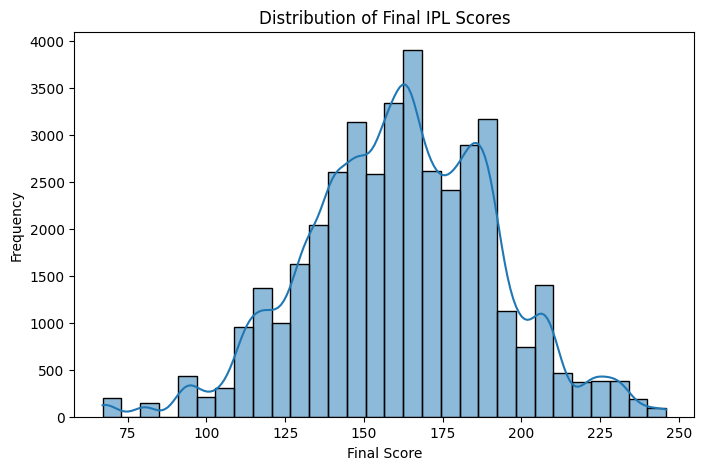

In [45]:
plt.figure(figsize=(8,5))

sns.histplot(data['total'], bins=30, kde=True)

plt.title("Distribution of Final IPL Scores")
plt.xlabel("Final Score")
plt.ylabel("Frequency")

plt.show()

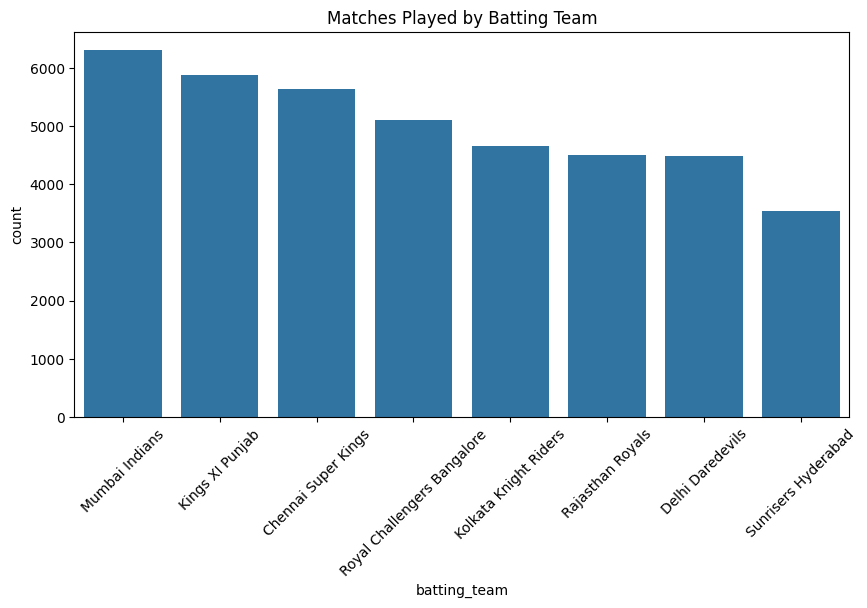

In [46]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=data,
    x='batting_team',
    order=data['batting_team'].value_counts().index
)

plt.xticks(rotation=45)
plt.title("Matches Played by Batting Team")

plt.show()

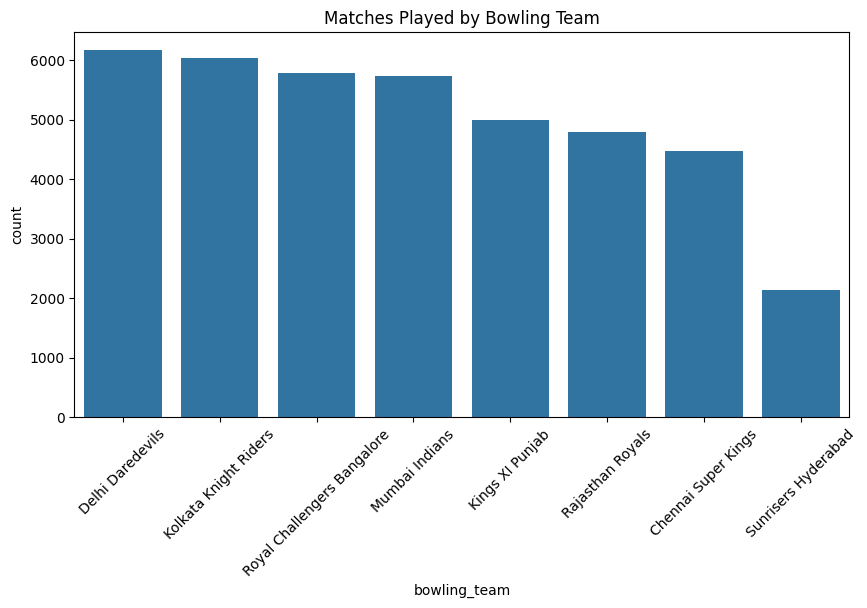

In [47]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=data,
    x='bowling_team',
    order=data['bowling_team'].value_counts().index
)

plt.xticks(rotation=45)
plt.title("Matches Played by Bowling Team")

plt.show()

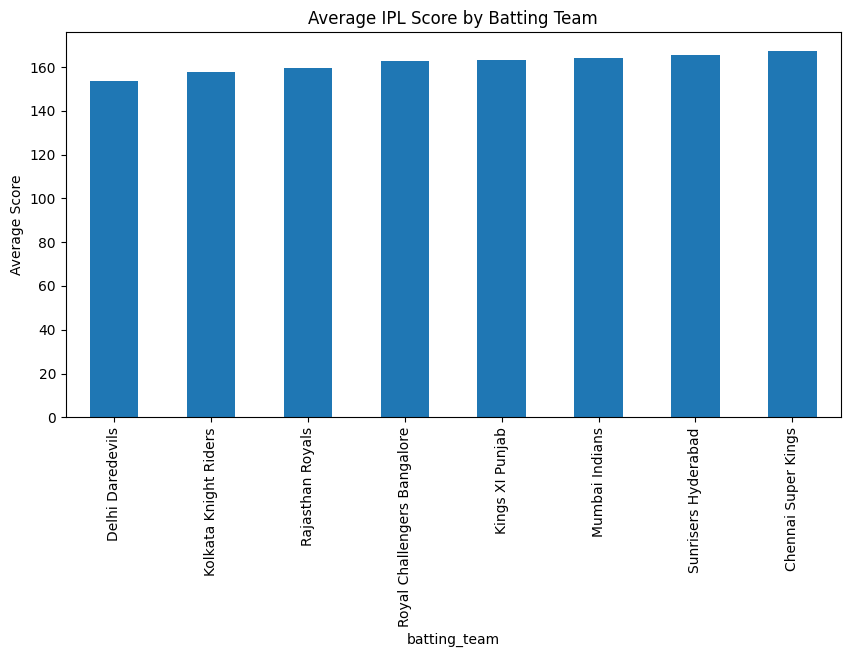

In [48]:
plt.figure(figsize=(10,5))

avg_score = data.groupby("batting_team")["total"].mean().sort_values()

avg_score.plot(kind="bar")

plt.ylabel("Average Score")
plt.title("Average IPL Score by Batting Team")

plt.show()

In [49]:
numeric_data = data.select_dtypes(include=['number'])

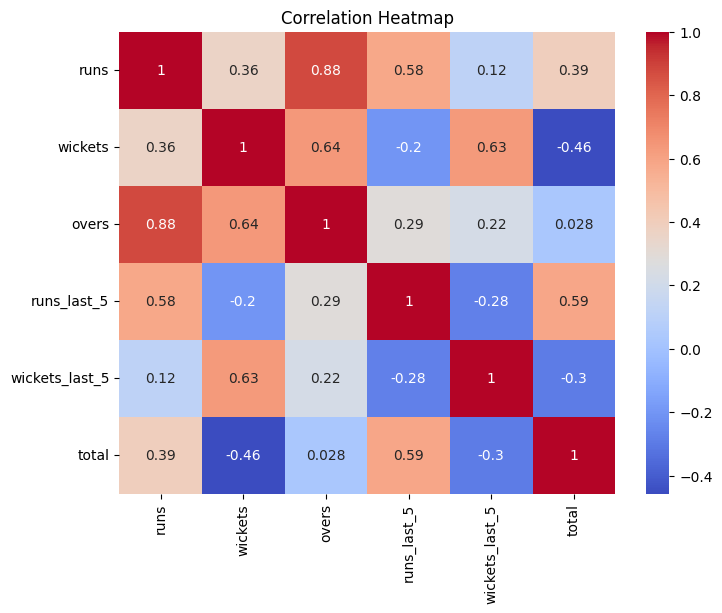

In [50]:
plt.figure(figsize=(8,6))

sns.heatmap(
    numeric_data.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

In [51]:
X = data.drop("total", axis=1)
Y = data["total"]

In [52]:
X = pd.get_dummies(
    X,
    columns=[
        "batting_team",
        "bowling_team",
        "venue"
    ],
    drop_first=True
)

In [53]:
print(X.shape)
print(Y.shape)

(40108, 49)
(40108,)


In [54]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(32086, 49)
(8022, 49)


## Machine Learning Model

The dataset was divided into training and testing sets.

Categorical features such as batting team, bowling team, and venue were converted into numerical values using One-Hot Encoding.

The target variable is the **final first innings score**, and multiple regression algorithms will be trained and compared to predict this score.

In [55]:
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor

from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

In [57]:
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(
        n_estimators=100,
        random_state=42
    ),
    "Lasso Regression": Lasso(alpha=0.1),
    "Support Vector Regressor": SVR(),
    "Neural Network": MLPRegressor(
        hidden_layer_sizes=(100,),
        max_iter=500,
        random_state=42
    )
}

results = []

for name, model in models.items():

    model.fit(X_train, Y_train)

    prediction = model.predict(X_test)

    r2 = r2_score(Y_test, prediction)
    mae = mean_absolute_error(Y_test, prediction)
    rmse = np.sqrt(mean_squared_error(Y_test, prediction))

    results.append([name, r2, mae, rmse])

results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "R² Score",
        "MAE",
        "RMSE"
    ]
)

results_df

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


,Model,R² Score,MAE,RMSE
0,Linear Regression,0.683662,12.619595,16.815431
1,Decision Tree,0.914502,2.595799,8.741996
2,Random Forest,0.959572,3.238139,6.011387
3,Lasso Regression,0.673581,12.764200,17.081252
4,Support Vector Regressor,0.579016,14.693592,19.398356
5,Neural Network,0.898675,6.652120,9.516793


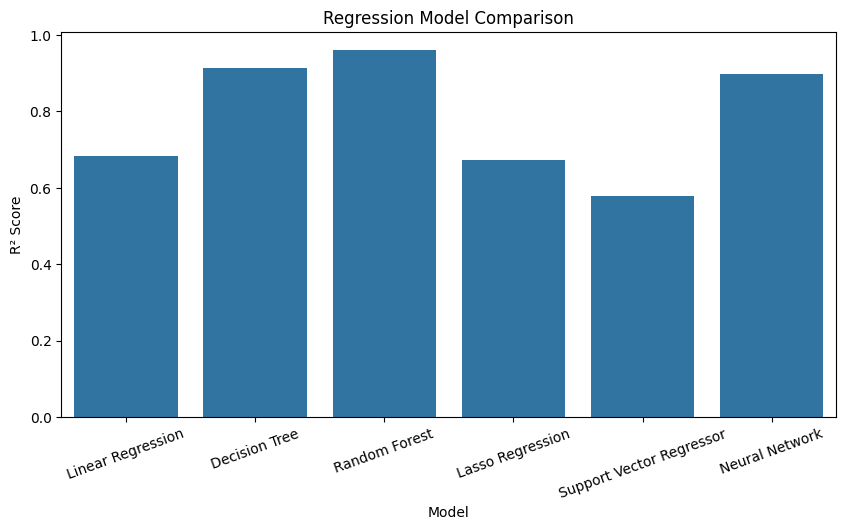

In [58]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=results_df,
    x="Model",
    y="R² Score"
)

plt.xticks(rotation=20)
plt.title("Regression Model Comparison")

plt.show()

In [59]:
best_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

best_model.fit(X_train, Y_train)

RandomForestRegressor(random_state=42)

In [60]:
prediction = best_model.predict(X_test)

comparison = pd.DataFrame({
    "Actual Score": Y_test.values,
    "Predicted Score": prediction.astype(int)
})

comparison.head(10)

,Actual Score,Predicted Score
0,208,205
1,195,191
2,184,168
3,132,131
4,163,162
5,170,168
6,117,121
7,112,111
8,119,120
9,141,136


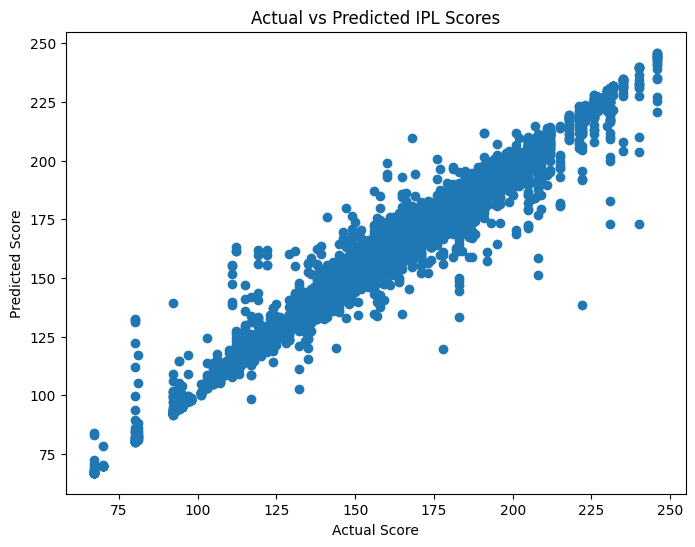

In [61]:
plt.figure(figsize=(8,6))

plt.scatter(Y_test, prediction)

plt.xlabel("Actual Score")
plt.ylabel("Predicted Score")
plt.title("Actual vs Predicted IPL Scores")

plt.show()

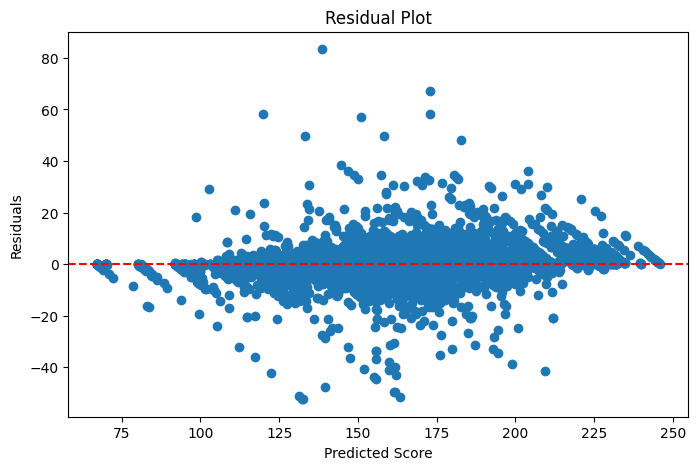

In [62]:
residuals = Y_test - prediction

plt.figure(figsize=(8,5))

plt.scatter(prediction, residuals)
plt.axhline(
    y=0,
    color="red",
    linestyle="--"
)

plt.xlabel("Predicted Score")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.show()

In [63]:
import joblib

joblib.dump(best_model, "ipl_score_prediction_model.pkl")

['ipl_score_prediction_model.pkl']

In [64]:
data.to_csv("cleaned_ipl_dataset.csv", index=False)

# Conclusion

In this project, an IPL First Innings Score Prediction model was developed using machine learning.

The dataset was cleaned and preprocessed by removing irrelevant columns, filtering consistent IPL teams, and excluding the first five overs. Exploratory Data Analysis (EDA) was performed to understand score distributions and team performance.

Multiple regression models were trained and evaluated, including:

- Linear Regression
- Decision Tree Regressor
- Random Forest Regressor
- Lasso Regression
- Support Vector Regressor
- Neural Network (MLP Regressor)

The best-performing model was selected based on evaluation metrics such as R² Score, Mean Absolute Error (MAE), and Root Mean Squared Error (RMSE).

The trained model can predict the final first innings score based on the current match situation, making it a useful demonstration of regression techniques in sports analytics.